In [1]:
import pandas as pd
import numpy as np

# =========================
# 1. 파일 불러오기
# =========================
file_path = "./data/공고원본_POSTING_ID포함_정리결과_hold반영_카테고리분류.xlsx"
sheet_name = "job_posting_processed"

df = pd.read_excel(file_path, sheet_name=sheet_name)

# =========================
# 2. 날짜 처리 및 대상 월 필터링
# =========================
df["POSTED_DATE"] = pd.to_datetime(df["POSTED_DATE"], errors="coerce")

target_months = ["2025-12", "2026-01", "2026-02"]
df["YEAR_MONTH"] = df["POSTED_DATE"].dt.strftime("%Y-%m")

df_target = df[df["YEAR_MONTH"].isin(target_months)].copy()

# =========================
# 3. 기술스택 문자열 분해
#    예: "Python, SQL, Docker" -> 각각 한 행으로 분리
# =========================
# 결측치 제거
df_target = df_target[df_target["TECH_STACK_NORMALIZED"].notna()].copy()

# 쉼표 기준 분리
df_target["TECH_STACK_LIST"] = df_target["TECH_STACK_NORMALIZED"].apply(
    lambda x: [s.strip() for s in str(x).split(",") if s.strip() != ""]
)

# 리스트를 행으로 펼치기
exploded = df_target[["YEAR_MONTH", "TECH_STACK_LIST"]].explode("TECH_STACK_LIST")
exploded = exploded.rename(columns={"TECH_STACK_LIST": "TECH_STACK"})

# =========================
# 4. 월별 기술스택 등장 횟수 집계
# =========================
monthly_counts = (
    exploded.groupby(["TECH_STACK", "YEAR_MONTH"])
    .size()
    .unstack(fill_value=0)
)

# 혹시 특정 월 컬럼이 없을 수도 있으니 강제로 맞춰줌
monthly_counts = monthly_counts.reindex(columns=target_months, fill_value=0)

# =========================
# 5. 증감률 계산
# =========================
# 2025-12 -> 2026-01
def calc_growth_rate(base, comp):
    if base > 0:
        return ((comp - base) / base) * 100
    elif base == 0 and comp > 0:
        return "신규"
    elif base == 0 and comp == 0:
        return 0
    else:
        return np.nan

monthly_counts["growth_2025-12_to_2026-01(%)"] = monthly_counts.apply(
    lambda row: calc_growth_rate(row["2025-12"], row["2026-01"]),
    axis=1
)

monthly_counts["growth_2026-01_to_2026-02(%)"] = monthly_counts.apply(
    lambda row: calc_growth_rate(row["2026-01"], row["2026-02"]),
    axis=1
)

# 보기 좋게 정렬
result = monthly_counts.reset_index().sort_values(
    by=["2026-02", "2026-01", "2025-12"],
    ascending=False
)

# =========================
# 6. 결과 확인
# =========================
print(result.head(30))

# =========================
# 7. 엑셀 저장
# =========================
output_path = "기술스택_월별등장횟수_및_증감률.xlsx"
result.to_excel(output_path, index=False)

print(f"\n저장 완료: {output_path}")

YEAR_MONTH   TECH_STACK  2025-12  2026-01  2026-02  \
25                 Java       23        7        3   
49               Python        7        4        2   
20                 HTML        6        8        1   
26           JavaScript       13        7        1   
53                React        8        5        1   
24                  JSP        6        5        1   
58               Spring        6        4        1   
74          전자정부표준프레임워크        3        3        1   
46               Oracle       13        2        1   
5                   AWS        7        1        1   
38                MySQL        4        1        1   
44              Node.js        4        0        1   
0                    AI        3        0        1   
48              PyTorch        2        0        1   
63           TensorFlow        1        0        1   
69            Websquare        1        0        1   
73                 머신러닝        1        0        1   
30                  LLM     

In [2]:
import pandas as pd
import numpy as np

# =========================
# 1. 파일 불러오기
# =========================
file_path = "./data/공고원본_POSTING_ID포함_정리결과_hold반영_카테고리분류.xlsx"
sheet_name = "job_posting_processed"

df = pd.read_excel(file_path, sheet_name=sheet_name)

# =========================
# 2. 날짜 처리
# =========================
df["POSTED_DATE"] = pd.to_datetime(df["POSTED_DATE"], errors="coerce")
df = df[df["POSTED_DATE"].notna()].copy()

df["YEAR_MONTH"] = df["POSTED_DATE"].dt.to_period("M").astype(str)

# =========================
# 3. 기술스택 분해
# =========================
df = df[df["TECH_STACK_NORMALIZED"].notna()].copy()

df["TECH_STACK_LIST"] = df["TECH_STACK_NORMALIZED"].apply(
    lambda x: [s.strip() for s in str(x).split(",") if s.strip()]
)

exploded = df[["YEAR_MONTH", "TECH_STACK_LIST"]].explode("TECH_STACK_LIST")
exploded = exploded.rename(columns={"TECH_STACK_LIST": "TECH_STACK"})

# =========================
# 4. 전체 기간 월별 집계표 만들기
# =========================
all_monthly_counts = (
    exploded.groupby(["TECH_STACK", "YEAR_MONTH"])
    .size()
    .unstack(fill_value=0)
)

# 월 순서 정렬
all_monthly_counts = all_monthly_counts.reindex(
    sorted(all_monthly_counts.columns),
    axis=1
)

# =========================
# 5. 분석 대상 월만 추출
# =========================
target_months = ["2025-12", "2026-01", "2026-02"]

monthly_counts = all_monthly_counts.reindex(columns=target_months, fill_value=0).copy()

# =========================
# 6. 증감률 계산 함수
# =========================
def calc_growth_rate(base, comp):
    if base > 0:
        return ((comp - base) / base) * 100
    elif base == 0 and comp > 0:
        return np.nan   # 상태 컬럼에서 첫등장/재등장으로 해석
    elif base == 0 and comp == 0:
        return 0
    else:
        return np.nan

# =========================
# 7. 상태 판정 함수
# =========================
def get_status(base, comp, had_before_base):
    """
    base: 기준월 값
    comp: 비교월 값
    had_before_base: 기준월 이전 전체 기간에 한 번이라도 등장한 적 있는지 (True/False)
    """
    if base > 0 and comp == 0:
        return "소멸"
    elif base == 0 and comp > 0:
        return "재등장" if had_before_base else "신규"
    elif base > 0 and comp > 0:
        if comp > base:
            return "증가"
        elif comp < base:
            return "감소"
        else:
            return "유지"
    elif base == 0 and comp == 0:
        return "없음"
    else:
        return np.nan

# =========================
# 8. 기준월 이전 등장 이력 계산 함수
# =========================
def had_appeared_before(row, base_month, full_table):
    """
    특정 키워드(row.name)가 base_month 이전에 한 번이라도 등장했는지 확인
    """
    earlier_months = [col for col in full_table.columns if col < base_month]
    if not earlier_months:
        return False
    return full_table.loc[row.name, earlier_months].sum() > 0

# =========================
# 9. 2025-12 -> 2026-01
#    기준월 이전 = 2025-12 이전 전체 기간
# =========================
monthly_counts["growth_2025-12_to_2026-01(%)"] = monthly_counts.apply(
    lambda row: calc_growth_rate(row["2025-12"], row["2026-01"]),
    axis=1
)

monthly_counts["status_2025-12_to_2026-01"] = monthly_counts.apply(
    lambda row: get_status(
        row["2025-12"],
        row["2026-01"],
        had_appeared_before(row, "2025-12", all_monthly_counts)
    ),
    axis=1
)

# =========================
# 10. 2026-01 -> 2026-02
#     기준월 이전 = 2026-01 이전 전체 기간
# =========================
monthly_counts["growth_2026-01_to_2026-02(%)"] = monthly_counts.apply(
    lambda row: calc_growth_rate(row["2026-01"], row["2026-02"]),
    axis=1
)

monthly_counts["status_2026-01_to_2026-02"] = monthly_counts.apply(
    lambda row: get_status(
        row["2026-01"],
        row["2026-02"],
        had_appeared_before(row, "2026-01", all_monthly_counts)
    ),
    axis=1
)

# =========================
# 11. 결과 정리
# =========================
result = monthly_counts.reset_index()

# 보기 좋게 정렬
result = result.sort_values(
    by=["2026-02", "2026-01", "2025-12", "TECH_STACK"],
    ascending=[False, False, False, True]
)

print(result.head(30))

# =========================
# 12. 엑셀 저장
# =========================
output_path = "기술스택_월별등장횟수_증감률_변화유형.xlsx"
result.to_excel(output_path, index=False)

print(f"\n저장 완료: {output_path}")

YEAR_MONTH   TECH_STACK  2025-12  2026-01  2026-02  \
78                 Java       23        7        3   
126              Python        7        4        2   
66                 HTML        6        8        1   
79           JavaScript       13        7        1   
136               React        8        5        1   
77                  JSP        6        5        1   
158              Spring        6        4        1   
198         전자정부표준프레임워크        3        3        1   
119              Oracle       13        2        1   
8                   AWS        7        1        1   
104               MySQL        4        1        1   
114             Node.js        4        0        1   
2                    AI        3        0        1   
125             PyTorch        2        0        1   
169          TensorFlow        1        0        1   
188           Websquare        1        0        1   
197                머신러닝        1        0        1   
86                  LLM     

In [8]:
import pandas as pd
import numpy as np

# =========================
# 1. 파일 불러오기
# =========================
file_path = "./data/공고원본_POSTING_ID포함_정리결과_hold반영_카테고리분류.xlsx"
sheet_name = "job_posting_processed"

df = pd.read_excel(file_path, sheet_name=sheet_name)

# =========================
# 2. 날짜 처리
# =========================
df["POSTED_DATE"] = pd.to_datetime(df["POSTED_DATE"], errors="coerce")
df = df[df["POSTED_DATE"].notna()].copy()
df["YEAR_MONTH"] = df["POSTED_DATE"].dt.to_period("M").astype(str)

# =========================
# 3. 월별 공고 수 집계
#    POSTING_ID가 있으면 고유 공고 수 기준
#    없으면 행 개수 기준
# =========================
if "POSTING_ID" in df.columns:
    monthly_posting_counts = (
        df.groupby("YEAR_MONTH")["POSTING_ID"]
        .nunique()
        .sort_index()
    )
else:
    monthly_posting_counts = (
        df.groupby("YEAR_MONTH")
        .size()
        .sort_index()
    )

# =========================
# 4. 기술스택 컬럼 전처리
# =========================
stack_df = df[df["TECH_STACK_NORMALIZED"].notna()].copy()

stack_df["TECH_STACK_LIST"] = stack_df["TECH_STACK_NORMALIZED"].apply(
    lambda x: [s.strip() for s in str(x).split(",") if s.strip()]
)

exploded = stack_df[["YEAR_MONTH", "TECH_STACK_LIST"]].explode("TECH_STACK_LIST")
exploded = exploded.rename(columns={"TECH_STACK_LIST": "TECH_STACK"})

# 빈 문자열 제거
exploded = exploded[exploded["TECH_STACK"].notna()].copy()
exploded = exploded[exploded["TECH_STACK"] != ""]

# =========================
# 5. 전체 기간 월별 기술스택 등장 횟수
# =========================
all_monthly_raw_counts = (
    exploded.groupby(["TECH_STACK", "YEAR_MONTH"])
    .size()
    .unstack(fill_value=0)
)

all_monthly_raw_counts = all_monthly_raw_counts.reindex(
    sorted(all_monthly_raw_counts.columns),
    axis=1
)

# =========================
# 6. 전체 기간 월별 정규화 비율
#    정규화 비율 = 기술스택 등장 횟수 / 해당 월 공고 수
# =========================
all_monthly_normalized = all_monthly_raw_counts.copy().astype(float)

for col in all_monthly_normalized.columns:
    posting_cnt = monthly_posting_counts.get(col, 0)
    if posting_cnt > 0:
        all_monthly_normalized[col] = all_monthly_normalized[col] / posting_cnt
    else:
        all_monthly_normalized[col] = np.nan

# =========================
# 7. 분석 대상 월 설정
# =========================
target_months = ["2025-10", "2025-11", "2025-12"]

target_raw = all_monthly_raw_counts.reindex(columns=target_months, fill_value=0).copy()
target_norm = all_monthly_normalized.reindex(columns=target_months).copy()

target_posting_counts = {m: monthly_posting_counts.get(m, 0) for m in target_months}

# =========================
# 8. 정규화 비율 기준 증감률 계산 함수
# =========================
def calc_growth_rate(base, comp):
    if pd.isna(base) or pd.isna(comp):
        return np.nan
    if base > 0:
        return ((comp - base) / base) * 100
    elif base == 0 and comp > 0:
        return np.nan
    elif base == 0 and comp == 0:
        return 0
    else:
        return np.nan

# =========================
# 9. 상태 판정 함수
#    상태는 raw count 기준으로 판단
# =========================
def get_status(base_raw, comp_raw, had_before_base):
    if base_raw > 0 and comp_raw == 0:
        return "소멸"
    elif base_raw == 0 and comp_raw > 0:
        return "재등장" if had_before_base else "첫등장"
    elif base_raw > 0 and comp_raw > 0:
        if comp_raw > base_raw:
            return "증가"
        elif comp_raw < base_raw:
            return "감소"
        else:
            return "유지"
    elif base_raw == 0 and comp_raw == 0:
        return "없음"
    else:
        return np.nan

def had_appeared_before(stack_name, base_month, full_raw_table):
    earlier_months = [col for col in full_raw_table.columns if col < base_month]
    if not earlier_months:
        return False
    return full_raw_table.loc[stack_name, earlier_months].sum() > 0

# =========================
# 10. 결과 테이블 생성
# =========================
result = pd.DataFrame(index=target_raw.index)

# 원본 등장 횟수
result["raw_count_2025-10"] = target_raw["2025-10"]
result["raw_count_2025-11"] = target_raw["2025-11"]
result["raw_count_2025-12"] = target_raw["2025-12"]

# 월별 공고 수
result["posting_count_2025-10"] = target_posting_counts["2025-10"]
result["posting_count_2025-11"] = target_posting_counts["2025-11"]
result["posting_count_2025-12"] = target_posting_counts["2025-12"]

# 정규화 비율
result["normalized_freq_2025-10"] = target_norm["2025-10"]
result["normalized_freq_2025-11"] = target_norm["2025-11"]
result["normalized_freq_2025-12"] = target_norm["2025-12"]

# 정규화 비율 기준 증감률
result["normalized_growth_2025-10_to_2025-11(%)"] = result.apply(
    lambda row: calc_growth_rate(
        row["normalized_freq_2025-10"],
        row["normalized_freq_2025-11"]
    ),
    axis=1
)

result["normalized_growth_2025-11_to_2025-12(%)"] = result.apply(
    lambda row: calc_growth_rate(
        row["normalized_freq_2025-11"],
        row["normalized_freq_2025-12"]
    ),
    axis=1
)

# 변화유형
result["status_2025-10_to_2025-11"] = result.apply(
    lambda row: get_status(
        row["raw_count_2025-10"],
        row["raw_count_2025-11"],
        had_appeared_before(row.name, "2025-10", all_monthly_raw_counts)
    ),
    axis=1
)

result["status_2025-11_to_2025-12"] = result.apply(
    lambda row: get_status(
        row["raw_count_2025-11"],
        row["raw_count_2025-12"],
        had_appeared_before(row.name, "2025-11", all_monthly_raw_counts)
    ),
    axis=1
)

# 인덱스를 컬럼으로
result = result.reset_index().rename(columns={"TECH_STACK": "tech_stack"})

# 보기 좋게 정렬
result = result.sort_values(
    by=[
        "normalized_freq_2025-12",
        "normalized_freq_2025-11",
        "normalized_freq_2025-10",
        "raw_count_2025-12"
    ],
    ascending=[False, False, False, False]
)

# =========================
# 11. 월별 공고 수 요약표
# =========================
posting_summary = pd.DataFrame({
    "YEAR_MONTH": target_months,
    "posting_count": [target_posting_counts[m] for m in target_months]
})

# =========================
# 12. 출력 확인
# =========================
print("=== 월별 공고 수 ===")
print(posting_summary)

print("\n=== 결과 미리보기 ===")
print(result.head(30))

# =========================
# 13. 엑셀 저장
# =========================
output_path = "기술스택_정규화트렌드분석_2025_10_11_12.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    result.to_excel(writer, sheet_name="trend_result", index=False)
    posting_summary.to_excel(writer, sheet_name="monthly_posting_count", index=False)
    target_raw.reset_index().to_excel(writer, sheet_name="raw_monthly_counts", index=False)
    target_norm.reset_index().to_excel(writer, sheet_name="normalized_monthly_freq", index=False)

print(f"\n저장 완료: {output_path}")

=== 월별 공고 수 ===
  YEAR_MONTH  posting_count
0    2025-10             53
1    2025-11             38
2    2025-12             45

=== 결과 미리보기 ===
      tech_stack  raw_count_2025-10  raw_count_2025-11  raw_count_2025-12  \
78          Java                 15                 14                 23   
119       Oracle                  7                  6                 13   
79    JavaScript                 10                  2                 13   
94         Linux                  5                  7                  9   
136        React                  9                  3                  8   
126       Python                 13                 10                  7   
145          SQL                  6                  4                  7   
8            AWS                  0                  3                  7   
77           JSP                  5                  6                  6   
158       Spring                  7                  4                  6   
5       

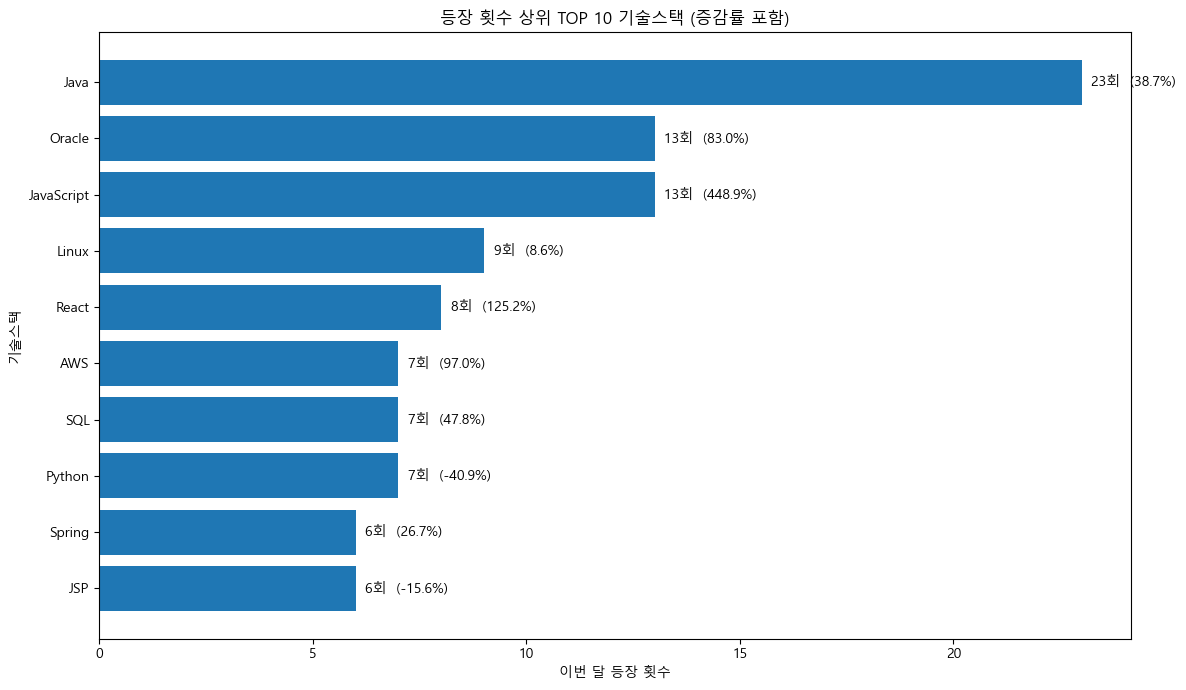

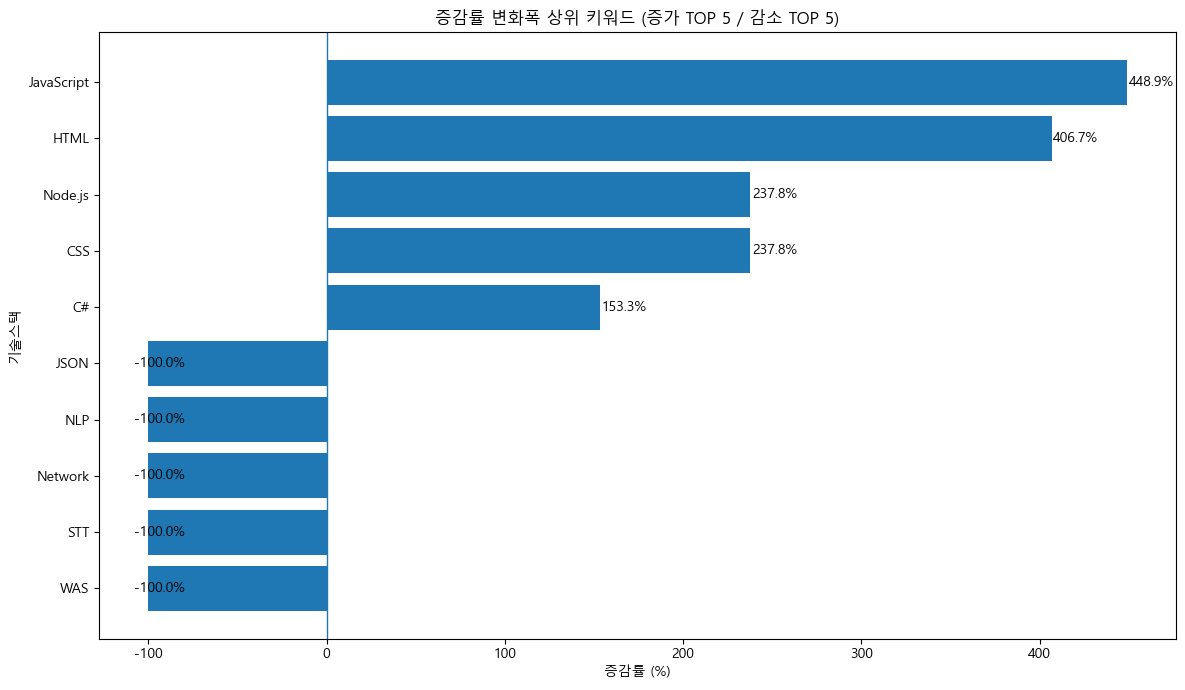

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0. 결과 파일 불러오기
#    이미 result 데이터프레임이 있으면 이 부분은 생략 가능
# =========================
file_path = "기술스택_정규화트렌드분석_2025_10_11_12.xlsx"
result = pd.read_excel(file_path, sheet_name="trend_result")

# =========================
# 1. 분석 기준 컬럼 설정
#    필요하면 여기만 바꿔서 다른 월 비교 가능
# =========================
current_month_col = "raw_count_2025-12"
growth_col = "normalized_growth_2025-11_to_2025-12(%)"
status_col = "status_2025-11_to_2025-12"
stack_col = "tech_stack"

# =========================
# 2. 한글 깨짐 방지
#    윈도우 기준: Malgun Gothic
# =========================
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# =========================
# 3. 그래프 1
#    등장 횟수가 많은 TOP 10 키워드 + 증감률 표시
# =========================
top10_count = result.sort_values(by=current_month_col, ascending=False).head(10).copy()

# 시각화용 정렬: 아래에서 위로 커지게 보이도록
top10_count = top10_count.sort_values(by=current_month_col, ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(top10_count[stack_col], top10_count[current_month_col])

plt.xlabel("이번 달 등장 횟수")
plt.ylabel("기술스택")
plt.title("등장 횟수 상위 TOP 10 기술스택 (증감률 포함)")

# 막대 끝에 등장 횟수 + 증감률 표시
for i, (_, row) in enumerate(top10_count.iterrows()):
    count_val = row[current_month_col]
    growth_val = row[growth_col]
    status_val = row[status_col]

    if pd.notna(growth_val):
        label = f"{int(count_val)}회  ({growth_val:.1f}%)"
    else:
        label = f"{int(count_val)}회  ({status_val})"

    plt.text(
        count_val + max(top10_count[current_month_col]) * 0.01,
        i,
        label,
        va="center"
    )

plt.tight_layout()
plt.savefig("top10_등장횟수_그래프.png", dpi=300, bbox_inches="tight")
plt.show()

# =========================
# 4. 그래프 2
#    증감률 증가 TOP 5 + 감소 TOP 5
#    NaN(첫등장/재등장)은 제외
# =========================
growth_df = result[result[growth_col].notna()].copy()

top5_positive = growth_df.sort_values(by=growth_col, ascending=False).head(5)
top5_negative = growth_df.sort_values(by=growth_col, ascending=True).head(5)

top10_growth = pd.concat([top5_negative, top5_positive], axis=0).copy()

# 중복 방지
top10_growth = top10_growth.drop_duplicates(subset=[stack_col])

# 보기 좋게 정렬
top10_growth = top10_growth.sort_values(by=growth_col, ascending=True)

plt.figure(figsize=(12, 7))
bars = plt.barh(top10_growth[stack_col], top10_growth[growth_col])

plt.xlabel("증감률 (%)")
plt.ylabel("기술스택")
plt.title("증감률 변화폭 상위 키워드 (증가 TOP 5 / 감소 TOP 5)")

# 막대 끝에 퍼센트 표시
for i, (_, row) in enumerate(top10_growth.iterrows()):
    growth_val = row[growth_col]
    plt.text(
        growth_val + (1 if growth_val >= 0 else -8),
        i,
        f"{growth_val:.1f}%",
        va="center"
    )

plt.axvline(0, linewidth=1)
plt.tight_layout()
plt.savefig("top5증가_top5감소_증감률그래프.png", dpi=300, bbox_inches="tight")
plt.show()